In [1]:
import cv2
import numpy as np
import os
import time
from sklearn.metrics import (precision_score, recall_score,
                              f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cấu hình đường dẫn

In [2]:

DATASET_PATH = '/kaggle/input/datasets/daohiep/fire-name'
 
TEST_IMG_DIR = f'{DATASET_PATH}/test/images'
TEST_LBL_DIR = f'{DATASET_PATH}/test/labels'
 
# Kết quả YOLO từ file results.csv (best epoch 105)
YOLO_RESULTS = {
    'Precision' : 0.8974,
    'Recall'    : 0.8609,
    'F1-Score'  : round(2 * 0.8974 * 0.8609 / (0.8974 + 0.8609), 4),
    'mAP50'     : 0.9022,
    'mAP50-95'  : 0.5985,
    'FPS'       : 0.0,    # ← điền FPS thực tế sau khi chạy inference
}
 
print(f" Dataset : {DATASET_PATH}")
print(f"   Test    : {len(os.listdir(TEST_IMG_DIR))} ảnh")
print(f"\n Kết quả YOLO (best epoch 105):")
for k, v in YOLO_RESULTS.items():
    print(f"   {k:12s}: {v}")

 Dataset : /kaggle/input/datasets/daohiep/fire-name
   Test    : 435 ảnh

 Kết quả YOLO (best epoch 105):
   Precision   : 0.8974
   Recall      : 0.8609
   F1-Score    : 0.8788
   mAP50       : 0.9022
   mAP50-95    : 0.5985
   FPS         : 0.0


HÀM PHÁT HIỆN LỬA BẰNG HSV

In [3]:
def detect_fire_hsv(image_path):
    
    # Đọc ảnh từ đường dẫn
    img = cv2.imread(image_path)
    if img is None:
        return False, None, None
 
    # ── Bước 1: Chuyển BGR → HSV ─────────────────────────
    # OpenCV đọc ảnh theo chuẩn BGR (khác với RGB thông thường)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
 
    # ── Bước 2: Tạo mask theo ngưỡng màu lửa ─────────────
 
    # Dải 1: cam – vàng – đỏ nhạt (H: 0~15, S cao, V cao)
    lower_fire1 = np.array([0,   100, 150])
    upper_fire1 = np.array([15,  255, 255])
    mask1 = cv2.inRange(hsv, lower_fire1, upper_fire1)
    # → Pixel nào trong dải này = 255 (trắng), ngoài dải = 0 (đen)
 
    # Dải 2: đỏ sẫm (H: 160~180, S cao, V cao)
    lower_fire2 = np.array([160, 100, 150])
    upper_fire2 = np.array([180, 255, 255])
    mask2 = cv2.inRange(hsv, lower_fire2, upper_fire2)
 
    # Gộp 2 mask bằng phép OR: pixel nào thuộc 1 trong 2 dải → giữ lại
    fire_mask = cv2.bitwise_or(mask1, mask2)
 
    # ── Bước 3: Lọc nhiễu bằng Morphological Operations ──
    kernel = np.ones((5, 5), np.uint8)
 
    # OPEN: xóa các vùng nhiễu nhỏ (< kernel)
    fire_mask = cv2.morphologyEx(fire_mask, cv2.MORPH_OPEN,  kernel)
    # CLOSE: lấp đầy lỗ nhỏ bên trong vùng lửa
    fire_mask = cv2.morphologyEx(fire_mask, cv2.MORPH_CLOSE, kernel)
 
    # ── Bước 4: Quyết định có lửa không ──────────────────
    h, w = img.shape[:2]
    total_pixels  = h * w
    fire_pixels   = np.sum(fire_mask > 0)
    fire_ratio    = fire_pixels / total_pixels
 
    # Có lửa khi vùng phát hiện chiếm > 1% diện tích ảnh
    detected = fire_ratio > 0.01
 
    return detected, fire_mask, img
 
 
print(" Hàm detect_fire_hsv() sẵn sàng!")
 

 Hàm detect_fire_hsv() sẵn sàng!


HÀM ĐỌC NHÃN YOLO

In [4]:
def get_ground_truth(label_path):

    if not os.path.exists(label_path):
        return False   # không có file nhãn = không có vật thể
 
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) >= 1 and int(parts[0]) == 0:
                return True   # tìm thấy class fire
 
    return False   # chỉ có class khác, không có lửa
 
 
print(" Hàm get_ground_truth() sẵn sàng!")

 Hàm get_ground_truth() sẵn sàng!


CHẠY ĐÁNH GIÁ HSV TRÊN TẬP TEST

In [5]:
y_true, y_pred = [], []
times          = []
 
# Lấy danh sách toàn bộ ảnh test
img_files = sorted([
    f for f in os.listdir(TEST_IMG_DIR)
    if f.endswith(('.jpg', '.png', '.jpeg'))
])
 
print(f" Bắt đầu đánh giá HSV trên {len(img_files)} ảnh test...")
print("-" * 50)
 
for i, img_file in enumerate(img_files):
    img_path = os.path.join(TEST_IMG_DIR, img_file)
    lbl_path = os.path.join(TEST_LBL_DIR,
                            img_file.rsplit('.', 1)[0] + '.txt')
 
    # Lấy nhãn thực tế từ file annotation
    gt = get_ground_truth(lbl_path)
 
    # Chạy HSV và đo thời gian inference
    t0 = time.time()
    pred, _, _ = detect_fire_hsv(img_path)
    times.append(time.time() - t0)
 
    y_true.append(int(gt))
    y_pred.append(int(pred if pred is not None else False))
 
    if (i + 1) % 100 == 0:
        print(f"   [{i+1:3d}/{len(img_files)}] đã xử lý...")
 
# Tính FPS trung bình
hsv_fps = 1 / np.mean(times)
 
# Tính các chỉ số đánh giá
hsv_precision = precision_score(y_true, y_pred, zero_division=0)
hsv_recall    = recall_score   (y_true, y_pred, zero_division=0)
hsv_f1        = f1_score       (y_true, y_pred, zero_division=0)
 
# In kết quả
print("\n" + "=" * 45)
print(" KẾT QUẢ HSV TRÊN TẬP TEST")
print("=" * 45)
print(f"   Precision  : {hsv_precision:.4f}")
print(f"   Recall     : {hsv_recall:.4f}")
print(f"   F1-Score   : {hsv_f1:.4f}")
print(f"   FPS        : {hsv_fps:.1f}")
print(f"   Tổng ảnh   : {len(y_true)}")
print(f"   Có lửa(GT) : {sum(y_true)}")
print(f"   Phát hiện  : {sum(y_pred)}")
print("=" * 45)
 
# Cập nhật FPS YOLO (điền vào sau khi có)
YOLO_RESULTS['FPS'] = 0.0   # ← thay bằng FPS thực tế của YOLO
 
# Lưu kết quả HSV ra CSV
pd.DataFrame([{
    'Method'   : 'HSV',
    'Precision': round(hsv_precision, 4),
    'Recall'   : round(hsv_recall,    4),
    'F1-Score' : round(hsv_f1,        4),
    'mAP50'    : 'N/A',
    'mAP50-95' : 'N/A',
    'FPS'      : round(hsv_fps, 1),
}]).to_csv('/kaggle/working/hsv_results.csv', index=False)
 
print("\n Đã lưu hsv_results.csv")

 Bắt đầu đánh giá HSV trên 435 ảnh test...
--------------------------------------------------
   [100/435] đã xử lý...
   [200/435] đã xử lý...
   [300/435] đã xử lý...
   [400/435] đã xử lý...

 KẾT QUẢ HSV TRÊN TẬP TEST
   Precision  : 0.9300
   Recall     : 0.7837
   F1-Score   : 0.8506
   FPS        : 82.7
   Tổng ảnh   : 435
   Có lửa(GT) : 356
   Phát hiện  : 300

 Đã lưu hsv_results.csv


CONFUSION MATRIX CỦA HSV

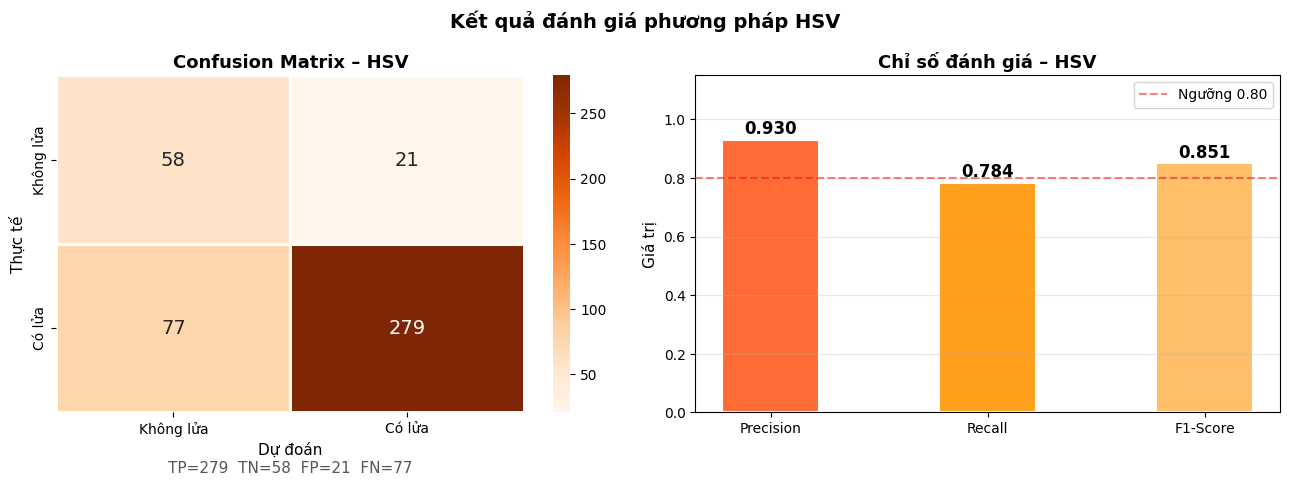

 Đã lưu hsv_evaluation.png


In [6]:
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Kết quả đánh giá phương pháp HSV',
             fontsize=14, fontweight='bold')
 
# ── Confusion Matrix ────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    ax=axes[0],
    xticklabels=['Không lửa', 'Có lửa'],
    yticklabels=['Không lửa', 'Có lửa'],
    linewidths=1, linecolor='white', annot_kws={'size': 14}
)
axes[0].set_title('Confusion Matrix – HSV', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Dự đoán', fontsize=11)
axes[0].set_ylabel('Thực tế', fontsize=11)
 
# Chú thích TP/TN/FP/FN
axes[0].text(0.5, -0.18,
    f'TP={tp}  TN={tn}  FP={fp}  FN={fn}',
    transform=axes[0].transAxes,
    ha='center', fontsize=11, color='#555'
)
 
# ── Bar chart chỉ số HSV ────────────────────────────────────
metrics = ['Precision', 'Recall', 'F1-Score']
values  = [hsv_precision, hsv_recall, hsv_f1]
colors  = ['#FF6B35', '#FF9F1C', '#FFBF69']
 
bars = axes[1].bar(metrics, values, color=colors,
                   width=0.45, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Chỉ số đánh giá – HSV', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Giá trị', fontsize=11)
axes[1].axhline(y=0.8, color='red', linestyle='--',
                alpha=0.5, label='Ngưỡng 0.80')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(fontsize=10)
 
for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.02, f'{val:.3f}',
        ha='center', fontweight='bold', fontsize=12
    )
 
plt.tight_layout()
plt.savefig('/kaggle/working/hsv_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu hsv_evaluation.png")

MINH HỌA ẢNH MẪU KẾT QUẢ HSV

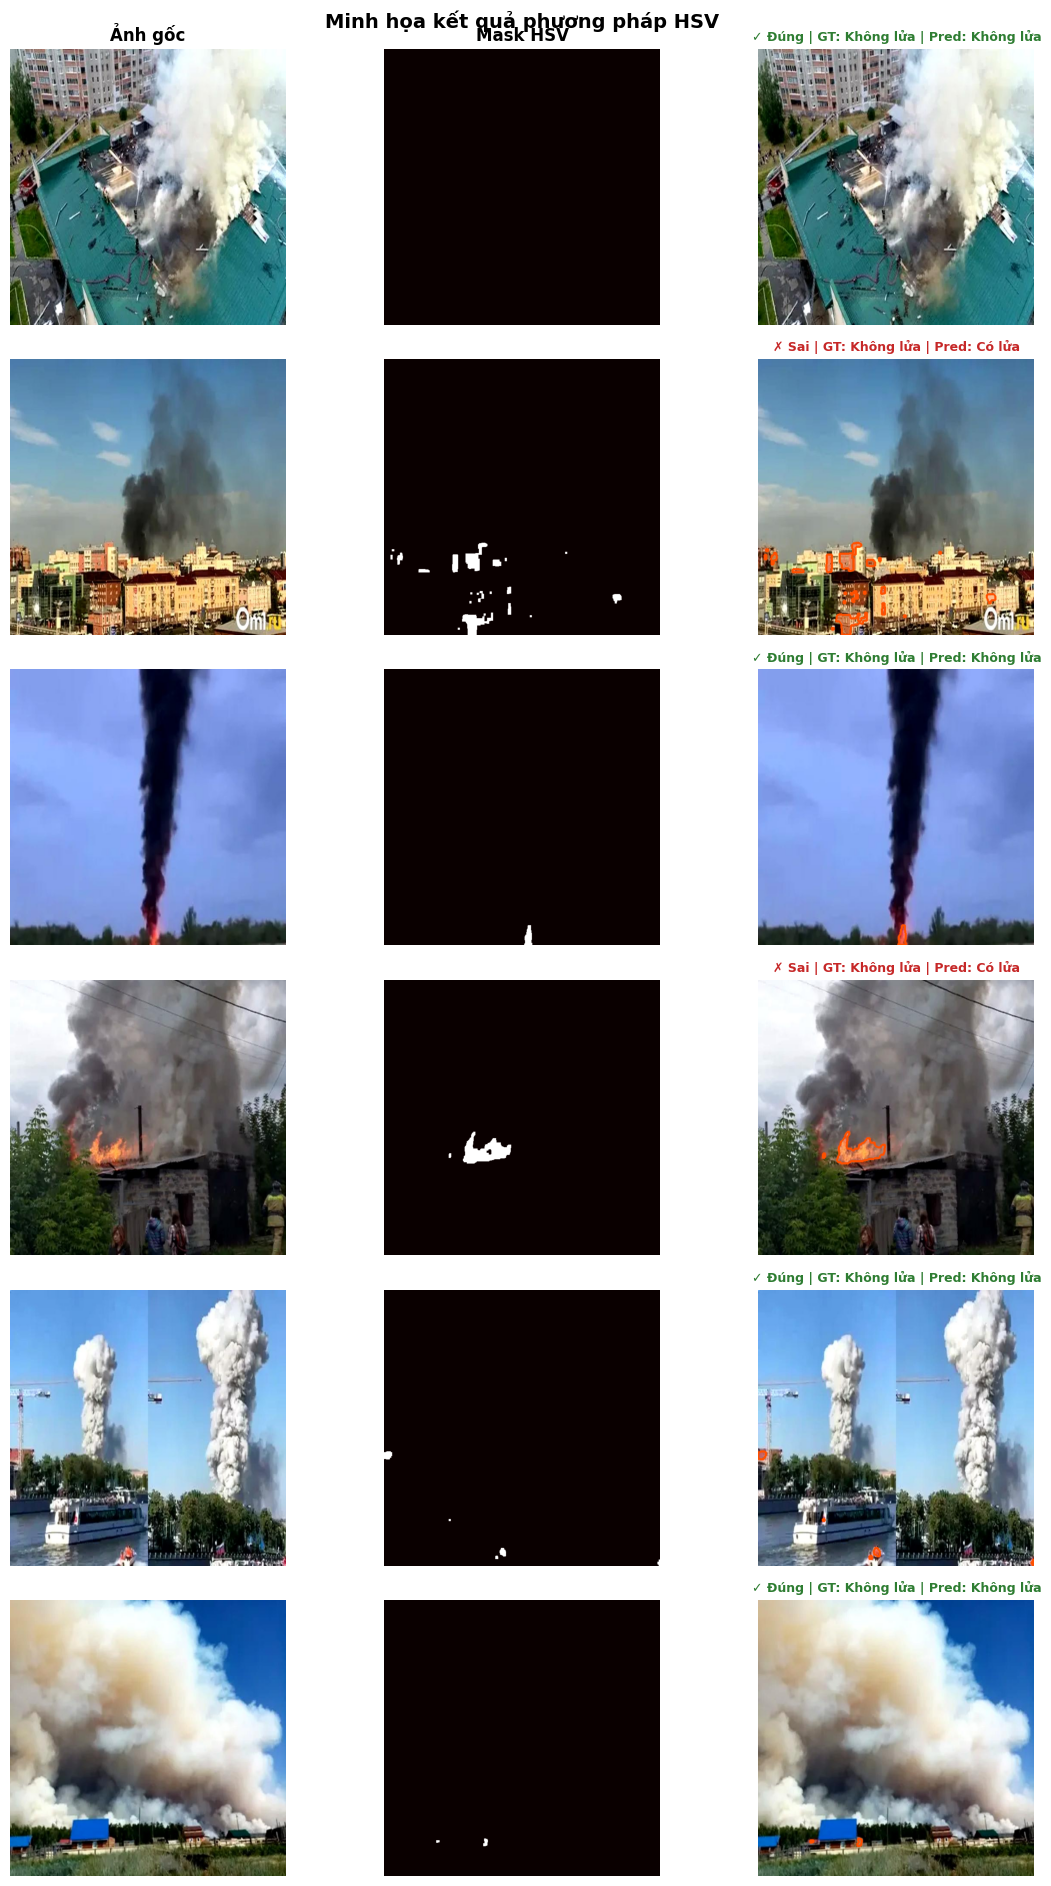

 Đã lưu hsv_samples.png


In [7]:
def visualize_hsv_samples(n=6):
    """
    Hiển thị n ảnh mẫu với 3 cột:
        Cột 1: Ảnh gốc
        Cột 2: Mask HSV (vùng phát hiện)
        Cột 3: Kết quả (đúng/sai so với nhãn thực tế)
    """
    sample_files = sorted(os.listdir(TEST_IMG_DIR))[:n]
 
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 3.2))
    fig.suptitle('Minh họa kết quả phương pháp HSV',
                 fontsize=14, fontweight='bold')
 
    col_titles = ['Ảnh gốc', 'Mask HSV', 'Kết quả']
    for col, title in enumerate(col_titles):
        axes[0][col].set_title(title, fontsize=12, fontweight='bold')
 
    for i, img_file in enumerate(sample_files):
        img_path = os.path.join(TEST_IMG_DIR, img_file)
        lbl_path = os.path.join(TEST_LBL_DIR,
                                img_file.rsplit('.', 1)[0] + '.txt')
 
        gt         = get_ground_truth(lbl_path)
        pred, mask, img = detect_fire_hsv(img_path)
        img_rgb    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
 
        # Vẽ contour vùng phát hiện lên ảnh kết quả
        result = img_rgb.copy()
        if mask is not None:
            contours, _ = cv2.findContours(
                mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            cv2.drawContours(result, contours, -1, (255, 80, 0), 3)
 
        # Màu tiêu đề: xanh = đúng, đỏ = sai
        is_correct = (pred == gt)
        title_color = '#2E7D32' if is_correct else '#C62828'
        status = '✓ Đúng' if is_correct else '✗ Sai'
        gt_label   = 'Có lửa' if gt   else 'Không lửa'
        pred_label = 'Có lửa' if pred else 'Không lửa'
 
        axes[i][0].imshow(img_rgb)
        axes[i][0].set_ylabel(f'Ảnh {i+1}', fontsize=9)
        axes[i][0].axis('off')
 
        if mask is not None:
            axes[i][1].imshow(mask, cmap='hot')
        axes[i][1].axis('off')
 
        axes[i][2].imshow(result)
        axes[i][2].set_title(
            f'{status} | GT: {gt_label} | Pred: {pred_label}',
            fontsize=9, color=title_color, fontweight='bold'
        )
        axes[i][2].axis('off')
 
    plt.tight_layout()
    plt.savefig('/kaggle/working/hsv_samples.png',
                dpi=130, bbox_inches='tight')
    plt.show()
    print(" Đã lưu hsv_samples.png")
 
visualize_hsv_samples(n=6)
 

In [8]:
# ════════════════════════════════════════════════════════════
# CELL ĐO FPS CỦA YOLOv11
# ════════════════════════════════════════════════════════════
from ultralytics import YOLO
import time
import os

# Load model best weights
model = YOLO('/kaggle/input/datasets/daohiep/data-final/run_9k_v2/weights/best.pt')

test_img_dir = '/kaggle/input/datasets/daohiep/fire-name/test/images'
img_files    = [f for f in os.listdir(test_img_dir)
                if f.endswith(('.jpg', '.png', '.jpeg'))]

# ── Chạy warmup trước (3 ảnh đầu không tính) ────────────────
# GPU cần "khởi động" trước khi đo tốc độ thực
print("🔥 Warmup GPU...")
for f in img_files[:3]:
    model.predict(os.path.join(test_img_dir, f),
                  verbose=False)

# ── Đo thời gian inference trên toàn bộ tập test ────────────
print(f"⏱️  Đang đo FPS trên {len(img_files)} ảnh...")
times = []

for f in img_files:
    img_path = os.path.join(test_img_dir, f)
    t0 = time.time()
    model.predict(img_path, conf=0.25, verbose=False)
    times.append(time.time() - t0)

# ── Kết quả ─────────────────────────────────────────────────
avg_time = sum(times) / len(times)
fps      = 1 / avg_time

print(f"\n✅ KẾT QUẢ FPS YOLOv11:")
print(f"   Thời gian trung bình / ảnh : {avg_time*1000:.2f} ms")
print(f"   FPS                        : {fps:.1f}")

ModuleNotFoundError: No module named 'ultralytics'

SO SÁNH HSV vs YOLOv11

In [ ]:
# Tổng hợp kết quả 2 phương pháp
comparison = {
    'HSV': {
        'Precision' : hsv_precision,
        'Recall'    : hsv_recall,
        'F1-Score'  : hsv_f1,
        'FPS'       : hsv_fps,
    },
    'YOLOv11': {
        'Precision' : YOLO_RESULTS['Precision'],
        'Recall'    : YOLO_RESULTS['Recall'],
        'F1-Score'  : YOLO_RESULTS['F1-Score'],
        'FPS'       : YOLO_RESULTS['FPS'],
    },
}
 
methods = list(comparison.keys())
colors  = {'HSV': '#FF6B35', 'YOLOv11': '#1565C0'}
 
fig = plt.figure(figsize=(18, 12))
fig.suptitle('So sánh HSV vs YOLOv11 – Phát hiện Lửa',
             fontsize=16, fontweight='bold', y=0.98)
 
# ── Biểu đồ 1: Precision / Recall / F1 ─────────────────────
ax1     = fig.add_subplot(2, 3, (1, 2))
metrics = ['Precision', 'Recall', 'F1-Score']
x       = np.arange(len(metrics))
width   = 0.32
 
for i, method in enumerate(methods):
    vals = [comparison[method][m] for m in metrics]
    bars = ax1.bar(x + i * width, vals, width,
                   label=method, color=colors[method],
                   edgecolor='white', linewidth=1.2, alpha=0.9)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 val + 0.01, f'{val:.3f}',
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
 
ax1.set_xticks(x + width / 2)
ax1.set_xticklabels(metrics, fontsize=12)
ax1.set_ylim(0, 1.18)
ax1.set_ylabel('Giá trị', fontsize=11)
ax1.set_title('Precision / Recall / F1-Score', fontsize=13, fontweight='bold')
ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.4, label='Ngưỡng 0.80')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
 
# ── Biểu đồ 2: FPS ──────────────────────────────────────────
ax2  = fig.add_subplot(2, 3, 3)
fps_vals = [comparison[m]['FPS'] for m in methods]
bars2 = ax2.bar(methods, fps_vals,
                color=[colors[m] for m in methods],
                width=0.45, edgecolor='white', linewidth=1.2, alpha=0.9)
for bar, val in zip(bars2, fps_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             val + max(fps_vals) * 0.02,
             f'{val:.1f}', ha='center', va='bottom',
             fontsize=12, fontweight='bold')
ax2.set_ylabel('FPS', fontsize=11)
ax2.set_title('Tốc độ xử lý (FPS)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
 
# ── Biểu đồ 3: Radar Chart ──────────────────────────────────
ax3        = fig.add_subplot(2, 3, (4, 5), polar=True)
categories = ['Precision', 'Recall', 'F1-Score']
N          = len(categories)
angles     = [n / float(N) * 2 * np.pi for n in range(N)]
angles    += angles[:1]
 
for method in methods:
    vals  = [comparison[method][m] for m in categories]
    vals += vals[:1]
    ax3.plot(angles, vals, 'o-', linewidth=2.5,
             label=method, color=colors[method])
    ax3.fill(angles, vals, alpha=0.12, color=colors[method])
 
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories, fontsize=12)
ax3.set_ylim(0, 1)
ax3.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax3.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8)
ax3.set_title('Radar Chart tổng hợp', fontsize=13,
              fontweight='bold', pad=20)
ax3.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax3.grid(True, alpha=0.3)
 
# ── Bảng số liệu ────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 6)
ax4.axis('off')
 
table_data = [
    ['Chỉ số',     'HSV',
     f'{comparison["HSV"]["Precision"]:.4f}',
     f'{comparison["YOLOv11"]["Precision"]:.4f}'],
    ['',           'Recall',
     f'{comparison["HSV"]["Recall"]:.4f}',
     f'{comparison["YOLOv11"]["Recall"]:.4f}'],
    ['',           'F1-Score',
     f'{comparison["HSV"]["F1-Score"]:.4f}',
     f'{comparison["YOLOv11"]["F1-Score"]:.4f}'],
    ['mAP@50',     'HSV: N/A',
     '',    f'{YOLO_RESULTS["mAP50"]:.4f}'],
    ['mAP@50-95',  'HSV: N/A',
     '',    f'{YOLO_RESULTS["mAP50-95"]:.4f}'],
    ['FPS',        '',
     f'{comparison["HSV"]["FPS"]:.1f}',
     f'{comparison["YOLOv11"]["FPS"]:.1f}'],
]
 
tbl = ax4.table(
    cellText=[
        ['Precision', f'{comparison["HSV"]["Precision"]:.4f}',
                      f'{comparison["YOLOv11"]["Precision"]:.4f}'],
        ['Recall',    f'{comparison["HSV"]["Recall"]:.4f}',
                      f'{comparison["YOLOv11"]["Recall"]:.4f}'],
        ['F1-Score',  f'{comparison["HSV"]["F1-Score"]:.4f}',
                      f'{comparison["YOLOv11"]["F1-Score"]:.4f}'],
        ['mAP@50',    'N/A',
                      f'{YOLO_RESULTS["mAP50"]:.4f}'],
        ['mAP@50-95', 'N/A',
                      f'{YOLO_RESULTS["mAP50-95"]:.4f}'],
        ['FPS',       f'{comparison["HSV"]["FPS"]:.1f}',
                      f'{comparison["YOLOv11"]["FPS"]:.1f}'],
    ],
    colLabels=['Chỉ số', 'HSV', 'YOLOv11'],
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
 
# Tô màu header
for j in range(3):
    tbl[(0, j)].set_facecolor('#37474F')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
 
# Tô màu cột HSV và YOLO
for i in range(1, 7):
    tbl[(i, 1)].set_facecolor('#FFF3E0')  # cam nhạt = HSV
    tbl[(i, 2)].set_facecolor('#E3F2FD')  # xanh nhạt = YOLO
 
ax4.set_title('Bảng so sánh', fontsize=13, fontweight='bold', pad=10)
 
plt.tight_layout()
plt.savefig('/kaggle/working/comparison_full.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
# In bảng tổng kết ra console
print("\n" + "=" * 55)
print("📊 BẢNG SO SÁNH TỔNG HỢP")
print("=" * 55)
print(f"{'Chỉ số':<14} {'HSV':>10} {'YOLOv11':>12}")
print("-" * 55)
for metric in ['Precision', 'Recall', 'F1-Score']:
    h = comparison['HSV'][metric]
    y = comparison['YOLOv11'][metric]
    winner = '← YOLO tốt hơn' if y > h else '← HSV tốt hơn'
    print(f"{metric:<14} {h:>10.4f} {y:>12.4f}   {winner}")
print(f"{'mAP@50':<14} {'N/A':>10} {YOLO_RESULTS['mAP50']:>12.4f}")
print(f"{'mAP@50-95':<14} {'N/A':>10} {YOLO_RESULTS['mAP50-95']:>12.4f}")
print(f"{'FPS':<14} {comparison['HSV']['FPS']:>10.1f} {comparison['YOLOv11']['FPS']:>12.1f}")
print("=" * 55)
 
print("\n✅ Đã lưu comparison_full.png")
print("✅ Hoàn thành toàn bộ đánh giá!")
 